# Deposit the density to a Cartesian grid
In this notebook we apply different kernels to deposit a scalar field (density) to a uniform Cartesian grid using the `DepositCartesianGrid` class

In [1]:
import paicos as pa
import numpy as np
import turbocluster as tc

pa.settings.strict_units = False

# A snapshot object
snap = pa.Snapshot(pa.data_dir, 247)
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([2000., 2000., 2000.], dtype=float)

threadsperblock = 64
npix = 256

In the following cells we initialize 4 different instances of `DepositCartesianGrid`, each with a different deposit kernel: NGP (nearest grid-point), CIC (cloud in cell), TSC (triangular shape function) and PCS (piecewise cubic spline)

In [2]:
depo_NGP = tc.DepositCartesianGrid(snap, center, widths, npix=npix, 
                                   threadsperblock=threadsperblock, 
                                   regionType='cartesian', kernel_type='NGP')

density_cartesian_NGP = depo_NGP.deposit_variable('0_Density', weight='0_Volume')


No `pos' argument given. Defaults to gas particles
No `hsml' argument given. Defaults to gas particles


In [3]:
depo_CIC = tc.DepositCartesianGrid(snap, center, widths, npix=npix, 
                                   threadsperblock=threadsperblock, 
                                   regionType='cartesian', kernel_type='CIC')

npoints = depo_CIC.npoints

density_cartesian_CIC = depo_CIC.deposit_variable('0_Density', weight='0_Volume')


No `pos' argument given. Defaults to gas particles
No `hsml' argument given. Defaults to gas particles


In [4]:
depo_TSC = tc.DepositCartesianGrid(snap, center, widths, npix=npix, 
                                   threadsperblock=threadsperblock, 
                                   regionType='cartesian', kernel_type="TSC",
                                   orientation=None)

density_cartesian_TSC = depo_TSC.deposit_variable(snap['0_Density'], weight='0_Volume')


No `pos' argument given. Defaults to gas particles
No `hsml' argument given. Defaults to gas particles


In [5]:
depo_PCS = tc.DepositCartesianGrid(snap, center, widths, npix=npix, 
                                   threadsperblock=threadsperblock, 
                                   regionType='cartesian', kernel_type="PCS")

density_cartesian_PCS = depo_PCS.deposit_variable('0_Density', weight='0_Volume')


No `pos' argument given. Defaults to gas particles
No `hsml' argument given. Defaults to gas particles


We initialize a Paicos `Slicer` object to compare with the Cartesian grids

In [6]:


widths_slicer = widths.copy()
widths_slicer[2] = 0.
slicer = pa.Slicer(snap, center, widths_slicer, 'z', npix=npix+1)
extent = slicer.centered_extent.to('Mpc')

We plot the mid-plane slice (z=0) of the four different densities, together with the slice obtained by using the Paicos Slicer

Text(0.5, 0.95, 'Density field (voronoi and cartesian)')

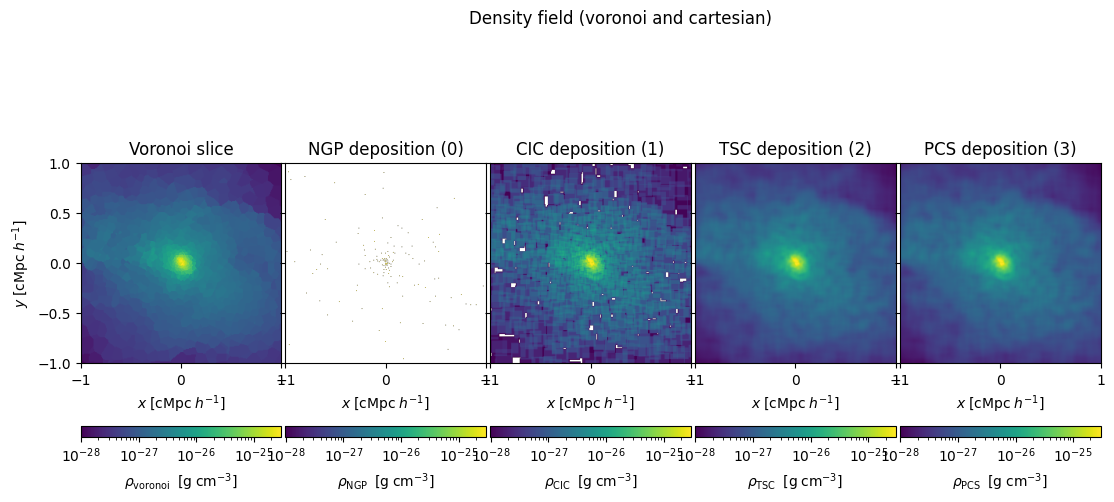

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

dens_voro = slicer.slice_variable('0_Density')
""" 
I am not sure why here I need to transpose to make sure
the alignment is the same as the slice
""" 
dens_cart_NGP = (density_cartesian_NGP[:,:,int(npoints[2]//2)-1].T).to_physical.cgs
dens_cart_CIC = (density_cartesian_CIC[:,:,int(npoints[2]//2)-1].T).to_physical.cgs
dens_cart_TSC = (density_cartesian_TSC[:,:,int(npoints[2]//2)-1].T).to_physical.cgs
dens_cart_PCS = (density_cartesian_PCS[:,:,int(npoints[2]//2)-1].T).to_physical.cgs

dens_voro = dens_voro.to_physical.cgs

vmin = np.min(dens_voro.value)
vmax = np.max(dens_voro.value)
norm = LogNorm(vmin=vmin,vmax=vmax)

fig, axes = plt.subplots(1,5, figsize=(12,6),sharex=True, sharey=True)

im1 = axes[0].imshow(
    dens_voro.value, origin='lower', norm=norm,extent=extent.value)

im2 = axes[1].imshow(
    dens_cart_NGP.value, origin='lower', norm=norm,extent=extent.value)

im3 = axes[2].imshow(
    dens_cart_CIC.value, origin='lower', norm=norm,extent=extent.value)

im4 = axes[3].imshow(
    dens_cart_TSC.value, origin='lower', norm=norm,extent=extent.value)

im5 = axes[4].imshow(
    dens_cart_PCS.value, origin='lower', norm=norm,extent=extent.value)


axes[0].set_title('Voronoi slice')
axes[1].set_title('NGP deposition (0)')
axes[2].set_title('CIC deposition (1)')
axes[3].set_title('TSC deposition (2)')
axes[4].set_title('PCS deposition (3)')


for i in range(5):
    axes[i].set_xlabel(extent.label('x'))

axes[0].set_ylabel(extent.label('y'))



cbar = fig.colorbar(im1, orientation='horizontal')
cbar.set_label(dens_voro.label('\\rho_{\\mathrm{voronoi}}'))

cbar = fig.colorbar(im2, orientation='horizontal')
cbar.set_label(dens_cart_NGP.label('\\rho_{\\mathrm{NGP}}'))

cbar = fig.colorbar(im3, orientation='horizontal')
cbar.set_label(dens_cart_CIC.label('\\rho_{\\mathrm{CIC}}'))

cbar = fig.colorbar(im4, orientation='horizontal')
cbar.set_label(dens_cart_TSC.label('\\rho_{\\mathrm{TSC}}'))

cbar = fig.colorbar(im5, orientation='horizontal')
cbar.set_label(dens_cart_PCS.label('\\rho_{\\mathrm{PCS}}'))


fig.subplots_adjust(top=0.85,
bottom=0.15,
left=0.05,
right=0.90,
hspace=0.0,
wspace=0.02)

fig.suptitle('Density field (voronoi and cartesian)',y=0.95)

## Test on a smaller sub-region

This is in order to check that the mass is exactly conserved with the different deposition kernels. 

I select a smaller region and zero-out the surroundings, so that even with different interpolations
the amount of mass contained in the smaller region does not change. 

Here the number of empty cells is not meaningful because it includes those zeroed-out.

In [8]:
depo_small = tc.DepositCartesianGrid(snap, center, widths/4,npix=npix, 
                                     threadsperblock=threadsperblock, regionType='cartesian',
                                    kernel_type='NGP')

No `pos' argument given. Defaults to gas particles
No `hsml' argument given. Defaults to gas particles


In [9]:
voxel = float(depo_NGP.tile.tile_widths[0]*depo_NGP.tile.tile_widths[1]*depo_NGP.tile.tile_widths[2])*snap['0_Volume'].unit

In [10]:
density_masked = np.zeros_like(snap['0_Density'])
density_masked[depo_small.index] = snap['0_Density'][depo_small.index]

This is the mass contained in the cubic region before depositing to grid

In [12]:
np.sum(density_masked * snap['0_Volume'])

<PaicosQuantity 2517.95780325 arepo_mass / small_h>

In [13]:
new_depo_NGP = tc.DepositCartesianGrid(snap, center, widths, npix=npix, threadsperblock=threadsperblock, 
               regionType='cartesian', kernel_type="NGP")
density_cartesian_small_NGP = new_depo_NGP.deposit_variable(density_masked, 
                                                          weight='0_Volume')

No `pos' argument given. Defaults to gas particles
No `hsml' argument given. Defaults to gas particles


In [14]:
np.sum(density_cartesian_small_NGP * voxel)

<PaicosQuantity 2517.95780325 arepo_mass / small_h>

In [15]:
new_depo_CIC = tc.DepositCartesianGrid(snap, center, widths, npix=npix, 
                                       threadsperblock=threadsperblock, 
                                       regionType='cartesian', kernel_type="CIC")
density_cartesian_small_CIC = new_depo_CIC.deposit_variable(density_masked, 
                                                          weight='0_Volume')

No `pos' argument given. Defaults to gas particles
No `hsml' argument given. Defaults to gas particles


In [16]:
np.sum(density_cartesian_small_CIC * voxel)

<PaicosQuantity 2517.95780325 arepo_mass / small_h>

In [17]:
new_depo_TSC = tc.DepositCartesianGrid(snap, center, widths, npix=npix, 
                                       threadsperblock=threadsperblock, 
                                       regionType='cartesian', kernel_type="TSC")
density_cartesian_small_TSC = new_depo_TSC.deposit_variable(density_masked, 
                                                    weight='0_Volume')

No `pos' argument given. Defaults to gas particles
No `hsml' argument given. Defaults to gas particles


In [18]:
np.sum(density_cartesian_small_TSC * voxel)

<PaicosQuantity 2517.95780325 arepo_mass / small_h>

In [19]:
new_depo_PCS = tc.DepositCartesianGrid(snap, center, widths, npix=npix, 
                                       threadsperblock=threadsperblock, 
                                       regionType='cartesian', kernel_type="PCS")
density_cartesian_small_PCS = new_depo_PCS.deposit_variable(density_masked, 
                                                    weight='0_Volume')

No `pos' argument given. Defaults to gas particles
No `hsml' argument given. Defaults to gas particles


In [20]:
np.sum(density_cartesian_small_PCS * voxel)

<PaicosQuantity 2517.95780325 arepo_mass / small_h>

The mass should be conserved with the different methods!